# Image Super-Resolution (SRCNN baseline)

Tässä notebookissa rakennetaan superresoluutio-malli TensorFlowlla käyttäen TFDS:n DIV2K-datasettiä.

Toteutus sisältää:
- DIV2K:n HR/LR-parit TFDS:n kautta
- patch-pohjaisen LR/HR-esikäsittelyn
- SRCNN-tyyppisen mallin (2x skaala)
- koulutuksen
- PSNR- ja SSIM-mittarit
- visuaalisen vertailun (bicubic, prediction ja HR)

Kun baseline toimii, seuraavat luonnolliset laajennukset ovat:
1. 4x skaalaus
2. perceptual loss
3. ESRGAN-tyyppinen malli

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE
SCALE = 2
PATCH_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 20

DATASET_NAME = "div2k/bicubic_x2"


train_raw = tfds.load(
    DATASET_NAME,
    split="train",
    as_supervised=True,
    shuffle_files=True,
)
val_raw = tfds.load(
    DATASET_NAME,
    split="validation",
    as_supervised=True,
    shuffle_files=False,
)
test_raw = tfds.load(
    DATASET_NAME,
    split="validation",
    as_supervised=True,
    shuffle_files=False,
)

print("DIV2K dataset loaded:", DATASET_NAME)

2026-05-06 20:05:37.759127: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 20:05:37.766791: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-06 20:05:37.777077: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-06 20:05:37.777096: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-06 20:05:37.783929: I tensorflow/core/platform/cpu_feature_gua

TensorFlow: 2.16.2
TFDS: 4.9.9


2026-05-06 20:05:39.892585: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-06 20:05:39.909524: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-06 20:05:39.913097: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

DIV2K dataset loaded: div2k/bicubic_x2


## Dataset: DIV2K

**DIV2K** (Diverse 2K resolution images) on erityisesti superresoluutiota varten suunniteltu datasetti.
Se sisältää 800 korkearesoluutioista kuvaa (2K eli 2048×1536) monista lähteistä.

### Miksi DIV2K?
- **Laatu**: Kuvat ovat ammattilaatuisia ja monipuolisia (luonto, kaupunki, ihmisiä, tekstuuri jne.)
- **Valmis LR/HR-parit**: TFDS sisältää valmiiksi bicubic-downsamplattuja versioita (2x, 3x, 4x)
- **Standardi**: Laajalti käytetty SR-tutkimuksessa, helppo vertailla tuloksia muihin malleihin

### Datan jako
- **Koulutus (90%)**: DIV2K training setin ensimmäinen 90 % → noin 720 kuvaa
- **Validointi (10%)**: DIV2K training setin viimeinen 10 % → noin 80 kuvaa  
- **Testaus**: DIV2K validation set → 100 kuvaa (virallinen benchmark)

Tässä käytetään `div2k/bicubic_x2` -konfiguraatiota, mikä tarkoittaa 2x magnifikaatiota bicubic-downsampluksella.

In [2]:
# TFDS DIV2K data pipeline
train_raw = tfds.load(
    DATASET_NAME,
    split="train[:90%]",
    as_supervised=True,
    shuffle_files=True,
)
val_raw = tfds.load(
    DATASET_NAME,
    split="train[90%:]",
    as_supervised=True,
    shuffle_files=False,
)
test_raw = tfds.load(
    DATASET_NAME,
    split="validation",
    as_supervised=True,
    shuffle_files=False,
)


def preprocess_pair(lr, hr):
    lr = tf.image.convert_image_dtype(lr, tf.float32)
    hr = tf.image.convert_image_dtype(hr, tf.float32)

    lr_patch_size = PATCH_SIZE // SCALE
    shape = tf.shape(lr)

    offset_y = tf.random.uniform([], 0, shape[0] - lr_patch_size + 1, dtype=tf.int32)
    offset_x = tf.random.uniform([], 0, shape[1] - lr_patch_size + 1, dtype=tf.int32)

    lr_patch = tf.image.crop_to_bounding_box(lr, offset_y, offset_x, lr_patch_size, lr_patch_size)
    hr_patch = tf.image.crop_to_bounding_box(hr, offset_y * SCALE, offset_x * SCALE, PATCH_SIZE, PATCH_SIZE)
    lr_upscaled = tf.image.resize(lr_patch, [PATCH_SIZE, PATCH_SIZE], method="bicubic")

    return lr_upscaled, hr_patch


def build_dataset(dataset, training=True):
    ds = dataset.map(preprocess_pair, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(256, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = build_dataset(train_raw, training=True)
val_ds = build_dataset(val_raw, training=False)
test_ds = build_dataset(test_raw, training=False)

print("Loaded TFDS DIV2K splits:")
print("- train: 90% of DIV2K train split")
print("- val: 10% of DIV2K train split")
print("- test: official DIV2K validation split")

Loaded TFDS DIV2K splits:
- train: 90% of DIV2K train split
- val: 10% of DIV2K train split
- test: official DIV2K validation split


## Example Images

Ennen koulutusta on hyödyllistä tarkastella, miltä DIV2K:n LR-syöte, bicubic-upscale ja HR-target näyttävät rinnakkain.
Tämä tekee baseline-vertailusta heti selkeän.

2026-05-06 20:05:41.459777: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


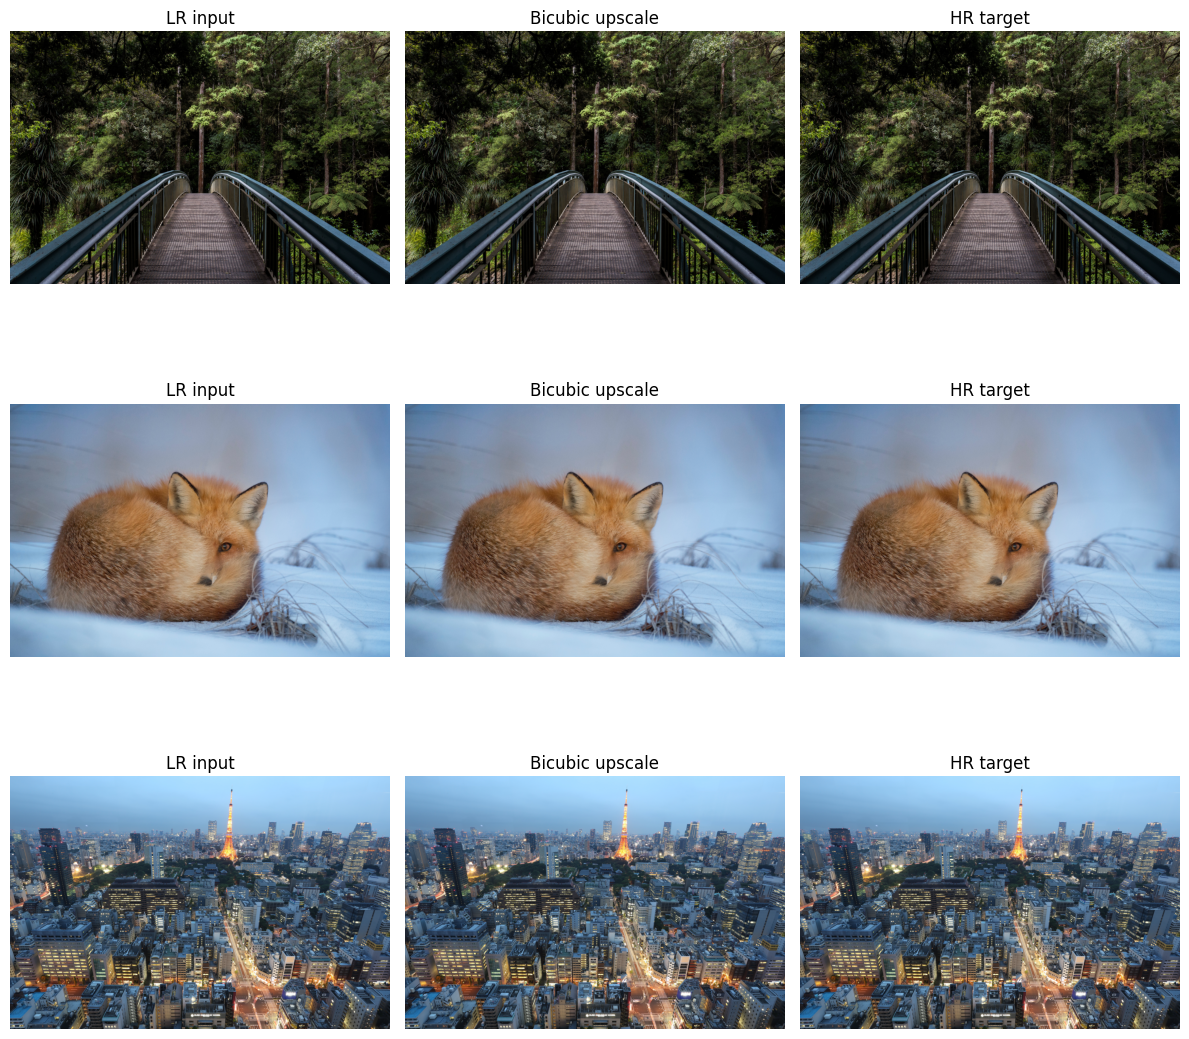

In [3]:
def show_example_images(dataset, num_examples=3):
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))

    for row, (lr, hr) in enumerate(dataset.take(num_examples)):
        lr = tf.image.convert_image_dtype(lr, tf.float32)
        hr = tf.image.convert_image_dtype(hr, tf.float32)
        bicubic = tf.image.resize(lr, tf.shape(hr)[:2], method="bicubic")

        images = [lr, bicubic, hr]
        titles = ["LR input", "Bicubic upscale", "HR target"]

        for col in range(3):
            axes[row, col].imshow(tf.clip_by_value(images[col], 0.0, 1.0))
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


show_example_images(test_raw, num_examples=3)

In [4]:
def build_srcnn(input_shape=(PATCH_SIZE, PATCH_SIZE, 3)):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(64, 9, padding="same", activation="relu")(inputs)
    x = layers.Conv2D(32, 1, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(3, 5, padding="same", activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="srcnn_x2")


model = build_srcnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.MeanAbsoluteError(),
    metrics=[keras.metrics.MeanSquaredError(name="mse")],
)
model.summary()

Model: "srcnn_x2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 3)    │         2,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,099 (78.51 KB)

 Trainable params: 20,099 (78.51 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20


I0000 00:00:1778087144.804183   87512 service.cc:145] XLA service 0x7f69e4017230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778087144.804217   87512 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-05-06 20:05:44.840369: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-06 20:05:44.955893: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 4/45 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.2491 - mse: 0.0813

I0000 00:00:1778087146.688267   87512 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.2320 - mse: 0.0736 - val_loss: 0.2353 - val_mse: 0.0761
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.2221 - mse: 0.0687 - val_loss: 0.2047 - val_mse: 0.0600
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.2041 - mse: 0.0589 - val_loss: 0.1787 - val_mse: 0.0481
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.1831 - mse: 0.0479 - val_loss: 0.1671 - val_mse: 0.0421
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.1566 - mse: 0.0356 - val_loss: 0.1298 - val_mse: 0.0257
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.1194 - mse: 0.0214 - val_loss: 0.0958 - val_mse: 0.0156
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0829 - mse: 0.0118 - val_loss: 0.0686 - val_mse: 0.0088
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0590 - mse: 0.0070 - val_loss: 0.0539 - val_mse: 0.0063
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0523 - mse: 0.

In [6]:
def batch_psnr(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))


def batch_ssim(y_true, y_pred):
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


psnr_values = []
ssim_values = []

for lr_batch, hr_batch in test_ds:
    sr_batch = model.predict(lr_batch, verbose=0)
    psnr_values.append(batch_psnr(hr_batch, sr_batch).numpy())
    ssim_values.append(batch_ssim(hr_batch, sr_batch).numpy())

print(f"Mean PSNR: {np.mean(psnr_values):.3f} dB")
print(f"Mean SSIM: {np.mean(ssim_values):.4f}")

Mean PSNR: 25.621 dB
Mean SSIM: 0.7363


2026-05-06 20:07:12.686067: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-05-06 20:07:40.505852: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


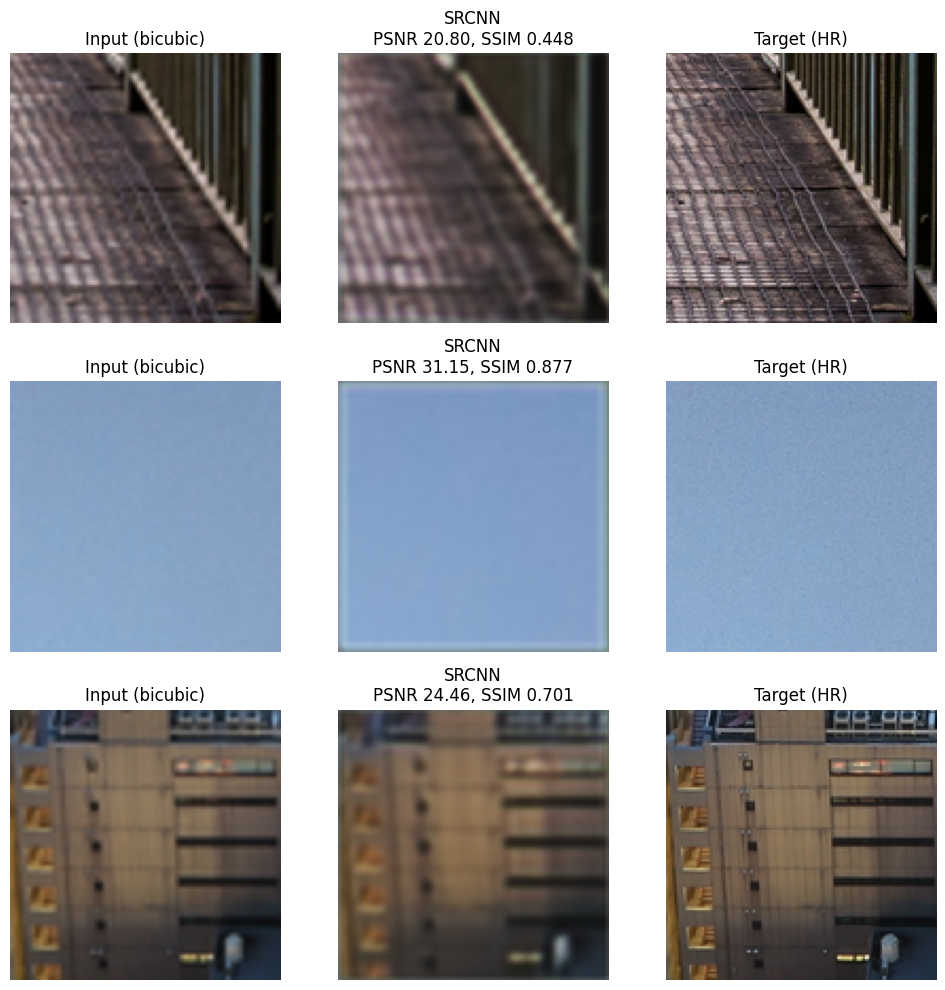

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for lr_batch, hr_batch in test_ds.take(1):
    sr_batch = model.predict(lr_batch, verbose=0)

    for i in range(3):
        lr_img = tf.clip_by_value(lr_batch[i], 0.0, 1.0).numpy()
        sr_img = tf.clip_by_value(sr_batch[i], 0.0, 1.0)
        hr_img = tf.clip_by_value(hr_batch[i], 0.0, 1.0).numpy()

        psnr_sr = tf.image.psnr(hr_batch[i], sr_img, max_val=1.0).numpy()
        ssim_sr = tf.image.ssim(hr_batch[i], sr_img, max_val=1.0).numpy()

        axes[i, 0].imshow(lr_img)
        axes[i, 0].set_title("Input (bicubic)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(sr_img)
        axes[i, 1].set_title(f"SRCNN\nPSNR {psnr_sr:.2f}, SSIM {ssim_sr:.3f}")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(hr_img)
        axes[i, 2].set_title("Target (HR)")
        axes[i, 2].axis("off")

plt.tight_layout()
plt.show()